<h1 style="color:green;font-size:22px;">Function 3 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;"">Introduction and illustrative analogy</h1>

**Function 3** is a three-dimensional black-box objective over the bounded domain $[0,1]^3$. Its analytical form and physical interpretation are unknown. The objective is to identify high-value input configurations under a limited sequential-query budget. The goal is to maximise **Function 3**.

As a purely illustrative analogy, consider a drug-discovery screening problem in which the three inputs represent quantities of three compounds and each experiment returns a single scalar screening score. The real black-box function has no known physical interpretation, so this analogy is intended only to illustrate sequential experimental design under a limited query budget. 

In this optimisation problem, the goal is to maximise **Function 3**.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as s
import warnings

from itertools import combinations
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from sklearn.exceptions import ConvergenceWarning

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel
warnings.filterwarnings("ignore", category=ConvergenceWarning)

<h1 style="color:#0000CD;font-size:19px;"">Week 1</h1>

**1.1 - Extraction of Initial Data**

In [37]:
inputs = np.load('Initial Data/function_3/initial_inputs.npy')
outputs = np.load('Initial Data/function_3/initial_outputs.npy')
print(inputs.shape, outputs.shape)

(15, 3) (15,)


In [38]:
data = pd.DataFrame(inputs, columns=['x1','x2','x3'])
data['y'] = outputs
display(data)

,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


**1.2 - Visual Data Exploration**

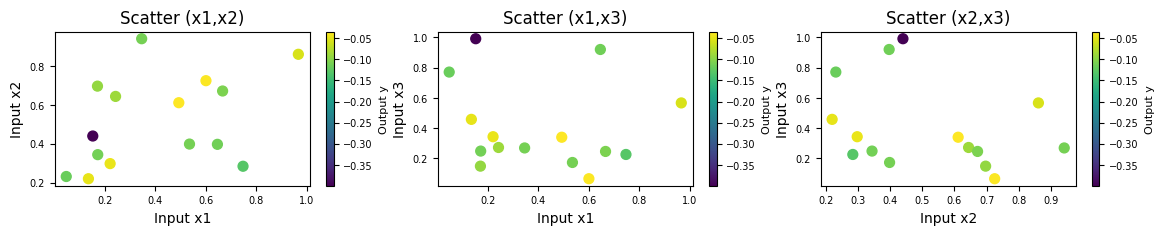

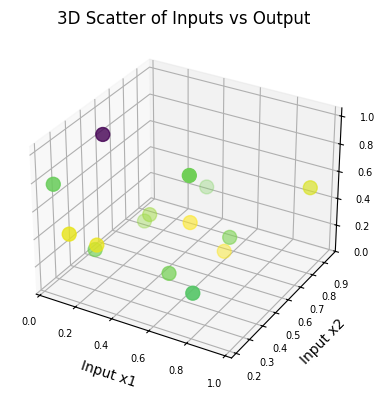

In [39]:
# Pairwise combinations
pairs = list(combinations(['x1', 'x2', 'x3'], 2))  # all unique pairs

# 2D scatter plots
fig, axes = plt.subplots(1, len(pairs), figsize=(14, 2))
#axes = axes.flatten() if len(pairs) > 1 else [axes]

for ax, (u, v) in zip(axes, pairs):
    sc = ax.scatter(data[u], data[v], c=data['y'], cmap='viridis', s=50)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Output y', fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    cbar.locator = mticker.MaxNLocator(nbins=8) 
    
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xlabel(f'Input {u}')
    ax.set_ylabel(f'Input {v}')
    ax.set_title(f'Scatter ({u},{v})')

# 3D scatter plot
fig2 = plt.figure(figsize=(5, 4))
ax2 = fig2.add_subplot(1, 1, 1, projection='3d')
sc3d = ax2.scatter(data['x1'], data['x2'], data['x3'], c=data['y'], cmap='viridis', s=100)
ax2.set_xlabel('Input x1')
ax2.set_ylabel('Input x2')
ax2.set_zlabel('Input x3')
ax2.set_title('3D Scatter of Inputs vs Output')
ax2.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


**Observations:**
- \$ (x_1, x_2, x_3) \in [0, 1]^3\$, \$y \in  [-0.398926, -0.034835]\$
- All outputs are negative.
- Most initial observations lie between approximately −0.14 and −0.03, while one observation is substantially lower at approximately −0.399.

**Deduction:**
- The sparse three-dimensional design does not establish the global shape of the objective.
- Several boundaries and corners remain weakly sampled, motivating an initial exploratory phase.
- The two strongest initial observations identify potentially promising areas, but there is not yet sufficient evidence to begin narrow local exploitation.

**1.3 - Bayesian Optimisation**

In [40]:
# Candidate points (grid)
x1 = np.linspace(0,1,50)
x2 = np.linspace(0,1,50)
x3 = np.linspace(0,1,50)
xx1, xx2, xx3 = np.meshgrid(x1, x2, x3)
X_grid = np.vstack([xx1.ravel(), xx2.ravel(),xx3.ravel()]).T

# GP Fit
kernel = RBF(length_scale=0.2) + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound
kappa = 1.5
ucb = y_pred + kappa * sigma
index_max = np.argmax(ucb)
next_point = np.array(X_grid[index_max], float)
print(f"Next point (with GP +UCB):{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}")


Next point (with GP +UCB):0.387755-0.408163-0.489796


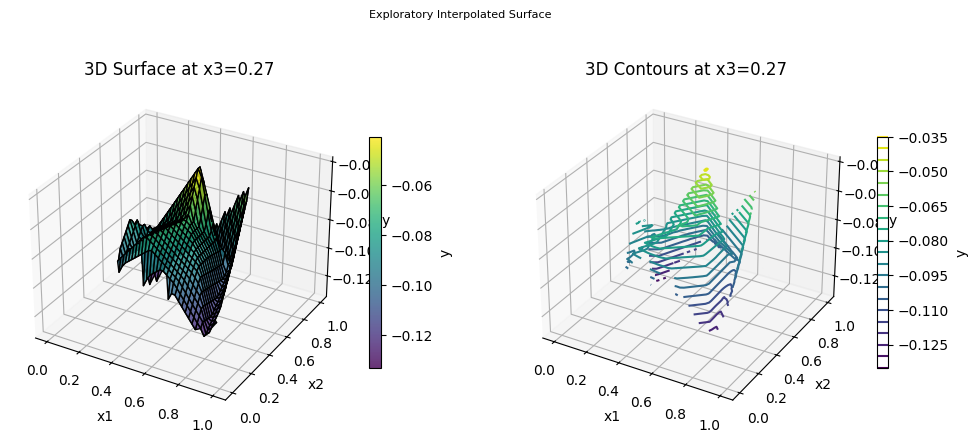

In [41]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

# Interpolate data to a grid for plotting
x1_lin = np.linspace(0,1,50)
x2_lin = np.linspace(0,1,50)
X1_grid, X2_grid = np.meshgrid(x1_lin, x2_lin)

# Fix x3 at median value
x3_fixed = np.median(data['x3'])
points = data[['x1','x2','x3']].values
values = data['y'].values
grid_z = griddata(points, values, (X1_grid, X2_grid, x3_fixed*np.ones_like(X1_grid)), method='linear')

# 3D Surface plot
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(X1_grid, X2_grid, grid_z, cmap='viridis', edgecolor='k', alpha=0.8)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title(f'3D Surface at x3={x3_fixed:.2f}')
fig.colorbar(surf, ax=ax, shrink=0.6, label='y')

# 3D Contour plot
ax2 = fig.add_subplot(122, projection='3d')
cont = ax2.contour3D(X1_grid, X2_grid, grid_z, 20, cmap='viridis')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('y')
ax2.set_title(f'3D Contours at x3={x3_fixed:.2f}')
fig.colorbar(cont, ax=ax2, shrink=0.6, label='y')
fig.suptitle("Exploratory Interpolated Surface", fontsize=8)
plt.show()


To provide qualitative intuition about the initial observations, the figures above present a linearly interpolated two-dimensional slice at the median observed value of x3. 

Because the initial dataset contains only 15 points distributed across the full three-dimensional domain, the interpolated shape should not be interpreted as an estimate of the true objective-function surface or as evidence of a global optimum. It is used only as an exploratory visual aid for identifying potentially higher-value regions.

**1.4 - Initial incumbent and Observed Ranges**

In [42]:
best = outputs.max()
field = outputs.max() - outputs.min()
print(best, field)

-0.034835313350078584 0.3640901997962225


<h1 style="color:#0000CD;font-size:19px;"">Week 2</h1>

**2.1 - Previous Week's Query Result**

In [43]:
# New Query Point
x_new = np.array([[0.387755, 0.408163, 0.489796]])
y_new = -0.0284170168056156

def add_QueriedPoint(data, x_new, y_new):

    inputs = data[['x1', 'x2','x3']].to_numpy()
    outputs = data['y'].to_numpy()
    
    # Checks if New Points is already included in data
    exists = False
    for i in range(inputs.shape[0]):
        if np.allclose(inputs[i], x_new) and np.isclose(outputs[i], y_new):
            exists = True
            break

    # Only adds if it doesn't exist already 
    if not exists:
        inputs = np.vstack([inputs, x_new])
        outputs = np.append(outputs, y_new)
        data = pd.DataFrame(inputs, columns=['x1', 'x2','x3']).assign(y=outputs)
    
        print("Point added!")
    else:
        print("Point already exists, skipping addition.")
    return data

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


**Deduction:**

- New point queried (0.387755-0.408163-0.489796) provided a new best observed value or incumbent (so far) y[15] = -0.0284170168056156.
- The first sequential query improved the incumbent from −0.034835 to −0.028417. However, one successful query is insufficient to establish a stable local optimum, so UCB exploration is retained for the next recommendation.

**2.2 - Next Point Query**

In [44]:
# GP Fit First
kernel = RBF(length_scale=0.2) + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound for exploration (optional, still using kappa)
kappa = 1.5
ucb = y_pred + kappa * sigma
index_ucb = np.argmax(ucb)
next_point_ucb = X_grid[index_ucb]

# Continue exploration using UCB
print("Continue UCB exploration")
next_point = next_point_ucb
print(f"Next point (UCB): {next_point}")

Continue UCB exploration
Next point (UCB): [0.36734694 0.14285714 0.42857143]


In [45]:
best = outputs.max()
field = outputs.max() - outputs.min()
print(best, field)

-0.0284170168056156 0.3705084963406855


<h1 style="color:#0000CD;font-size:19px;"">Week 3</h1>

**3.1 - Previous Week's Query Result**

In [46]:
# New Query Point
x_new = np.array([[0.36734694, 0.14285714, 0.42857143]])
y_new = -0.03288968924681542

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


**3.2 - Next Point Query**

In [47]:
# GP Fit First
kernel = RBF(length_scale=0.2) + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound for exploration (optional, still using kappa)
kappa = 1.5
ucb = y_pred + kappa * sigma
index_ucb = np.argmax(ucb)
next_point_ucb = X_grid[index_ucb]

# Continue exploration using UCB
print("Continue UCB exploration")
next_point = next_point_ucb
print(f"Next point (UCB): {next_point}")

Continue UCB exploration
Next point (UCB): [0.40816327 0.7755102  0.        ]


<h1 style="color:#0000CD;font-size:19px;"">Week 4</h1>

**4.1 - Previous Week's Query Result**

In [48]:
# New Query Point
x_new = np.array([[0.40816327, 0.7755102, 0]])
y_new = -0.11321689831417296

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


In [49]:
best = outputs.max()
field = outputs.max() - outputs.min()
print(best, field)

-0.0284170168056156 0.3705084963406855


**4.2 - Next Point Query**

The previous two recommendations did not improve the incumbent. For the next query, the UCB exploration weight is temporarily increased from 1.5 to 4.0 to force a stronger global exploratory step.

In [50]:
# GP Fit First
kernel = RBF(length_scale=0.2) + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound for exploration (optional, still using kappa)
kappa = 4
ucb = y_pred + kappa * sigma
index_ucb = np.argmax(ucb)
next_point_ucb = X_grid[index_ucb]

# Continue exploration using UCB
print("Continue UCB exploration")
next_point = next_point_ucb
print(f"Next point (UCB): {next_point}")

Continue UCB exploration
Next point (UCB): [0.79591837 0.95918367 0.        ]


<h1 style="color:#0000CD;font-size:19px;"">Week 5</h1>

**5.1 - Previous Week's Query Result**

In [51]:
# New Query Point
x_new = np.array([[0.795918, 0.9591834, 0]])
y_new = -0.14042073122255125

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


In [52]:
best = outputs.max()
field = outputs.max() - outputs.min()
print(best, field)

-0.0284170168056156 0.3705084963406855


**5.2 - Next Point Query (Adaptive UCB vs EI Comparison)**

From Week 5 onward, the UCB exploration weight follows the heuristic schedule $kappa=2/sqrt(t)$. <br>
This schedule is used to reduce the relative exploration weight over successive rounds and is not presented as the theoretical GP-UCB confidence schedule.

In [53]:
# Increase resolution Candidate points (grid)
x1 = np.linspace(0,1,100)
x2 = np.linspace(0,1,100)
x3 = np.linspace(0,1,100)
xx1, xx2, xx3 = np.meshgrid(x1, x2, x3)
X_grid = np.vstack([xx1.ravel(), xx2.ravel(),xx3.ravel()]).T

# GP Fit First
kernel = RBF(length_scale=0.2) + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)
      
# Pure EI
f_max_obs = max(outputs)
improvement = y_pred - f_max_obs
Z = improvement / sigma
ei = improvement * s.norm.cdf(Z) + sigma * s.norm.pdf(Z)
ei[sigma == 0.0] = 0.0  # avoid divide by zero
index_ei = np.argmax(ei)
next_point_ei = X_grid[index_ei]
print(f"Next point (EI): {next_point_ei}")
    
# Adaptive UCB
kappa = 2/ np.sqrt(5)
ucb = y_pred + kappa * sigma
index_ucb = np.argmax(ucb)
next_point_ucb = X_grid[index_ucb]
print(f"Next point (UCB): {next_point_ucb}")

Next point (EI): [0.31313131 0.27272727 0.45454545]
Next point (UCB): [0.3030303  0.27272727 0.48484848]


The UCB candidate is selected because it provides the more exploratory recommendation at this stage.

<h1 style="color:#0000CD;font-size:19px;"">Week 6</h1>

**6.1 - Previous Week's Query Result**

In [54]:
# New Query Point
x_new = np.array([[0.303030, 0.272727, 0.484848]])
y_new = -0.06129346056841814

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


**6.2 - Next Point Query (Adaptive UCB vs EI Comparison)**

The preceding UCB query did not improve the incumbent. The EI candidate is therefore selected to place greater emphasis on predicted improvement.

In [55]:
# GP Fit First
kernel = RBF(length_scale=0.2) + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)
    
# Pure EI
f_max_obs = max(outputs)
improvement = y_pred - f_max_obs
Z = improvement / sigma
ei = improvement * s.norm.cdf(Z) + sigma * s.norm.pdf(Z)
ei[sigma == 0.0] = 0.0  # avoid divide by zero
index_ei = np.argmax(ei)
next_point_ei = X_grid[index_ei]
print(f"Next point (EI): {next_point_ei}")
    
# Adaptive UCB
kappa = 2/ np.sqrt(6)
ucb = y_pred + kappa * sigma
index_ucb = np.argmax(ucb)
next_point_ucb = X_grid[index_ucb]
print(f"Next point (UCB): {next_point_ucb}")

Next point (EI): [0.43434343 0.52525253 0.44444444]
Next point (UCB): [0.43434343 0.56565657 0.48484848]


The EI candidate is selected to place greater emphasis on improvement around regions already associated with stronger observations.

<h1 style="color:#0000CD;font-size:19px;"">Week 7</h1>

**7.1 - Previous Week's Query Result**

In [56]:
# New Query Point
x_new = np.array([[0.434343, 0.525253, 0.444444]])
y_new = -0.007682403746215934

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


**7.2 - Next Point Query (Adaptive UCB vs EI Comparison)**

In [57]:
# GP Fit First
kernel = RBF(length_scale=0.2) + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)
    
# Pure EI
f_max_obs = max(outputs)
improvement = y_pred - f_max_obs
Z = improvement / sigma
ei = improvement * s.norm.cdf(Z) + sigma * s.norm.pdf(Z)
ei[sigma == 0.0] = 0.0  # avoid divide by zero
index_ei = np.argmax(ei)
next_point_ei = X_grid[index_ei]
print(f"Next point (EI): {next_point_ei}")
    
# Adaptive UCB
kappa = 2/ np.sqrt(7)
ucb = y_pred + kappa * sigma
index_ucb = np.argmax(ucb)
next_point_ucb = X_grid[index_ucb]
print(f"Next point (UCB): {next_point_ucb}")

Next point (EI): [0.25252525 0.06060606 0.31313131]
Next point (UCB): [0.26262626 0.08080808 0.31313131]


The EI candidate is selected. Although the preceding EI query improved the incumbent substantially, the global search is retained for one additional round before restricting the candidate region.

<h1 style="color:#0000CD;font-size:19px;"">Week 8</h1>

**8.1 - Previous Week's Query Result**

In [58]:
# New Query Point
x_new = np.array([[0.252525, 0.060606, 0.313131]])
y_new = -0.13467258479873287

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


**8.2 - Next Point Query (Global EI Recommendation)**

In [59]:
# GP Fit First
kernel = RBF(length_scale=0.2) + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)
    
# Pure EI
f_max_obs = max(outputs)
improvement = y_pred - f_max_obs
Z = improvement / sigma
ei = improvement * s.norm.cdf(Z) + sigma * s.norm.pdf(Z)
ei[sigma == 0.0] = 0.0  # avoid divide by zero
index_ei = np.argmax(ei)
next_point_ei = X_grid[index_ei]
print(f"Next point (EI): {next_point_ei}")
    
# Adaptive UCB
kappa = 2/ np.sqrt(8)
ucb = y_pred + kappa * sigma
index_ucb = np.argmax(ucb)
next_point_ucb = X_grid[index_ucb]
print(f"Next point (UCB): {next_point_ucb}")

Next point (EI): [0.41414141 0.42424242 0.37373737]
Next point (UCB): [0.41414141 0.44444444 0.38383838]


<h1 style="color:#0000CD;font-size:19px;"">Week 9</h1>

**9.1 - Previous Week's Query Result**

In [60]:
# New Query Point
x_new = np.array([[0.414141, 0.424242, 0.373737]])
y_new = -0.01987647572771442

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


The returned value of −0.019876 did not improve the incumbent, but it was materially stronger than most earlier observations. Together with the incumbent at [0.434343, 0.525253, 0.444444], it supports further investigation of the surrounding region.

The next phase restricts EI candidates to a local box with a fixed half-width of ±0.05 in each dimension, re-centred on the current incumbent at each round. This is a heuristic local search box rather than a formal adaptive trust region.

For the local phase, the surrogate is also changed from the earlier RBF-plus-noise specification to an anisotropic Matérn-5/2 model. This represents a deliberate heuristic phase change rather than a formal adaptive trust-region algorithm.

**9.2 - Next Point Query (Local EI Recommendation)**

In [61]:
# Current best observed point

best_idx = np.argmax(outputs)
x_best = inputs[best_idx]
y_best = outputs[best_idx]
print("Current best x:", x_best, "Current best y:", y_best)

# GP surrogate

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=np.array([0.08, 0.08, 0.08]),
    length_scale_bounds=(1e-3, 0.5),
    nu=2.5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-8,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42)

gp.fit(inputs, outputs)

# Local candidate generation

radius = np.array([0.05, 0.05, 0.05])
n_candidates = 100_000

rng = np.random.default_rng(42)

lower = np.maximum(0.0, x_best - radius)
upper = np.minimum(1.0, x_best + radius)

X_cand = rng.uniform(
    low=lower,
    high=upper,
    size=(n_candidates, inputs.shape[1]))

# Remove points already queried

min_dist = np.min(
    np.linalg.norm(X_cand[:, None, :] - inputs[None, :, :], axis=2),
    axis=1
)

X_cand = X_cand[min_dist > 1e-6]

# Expected Improvement

mu, sigma = gp.predict(X_cand, return_std=True)
sigma = np.maximum(sigma, 1e-12)

xi = 0.001   # mild exploitation, not too greedy

improvement = mu - y_best - xi
z = improvement / sigma

EI = improvement * s.norm.cdf(z) + sigma * s.norm.pdf(z)

next_x = X_cand[np.argmax(EI)]

print("\nNext Local EI query:")
print(next_x)

Current best x: [0.434343 0.525253 0.444444] Current best y: -0.007682403746215934

Next Local EI query:
[0.48333142 0.57403091 0.49368092]


<h1 style="color:#0000CD;font-size:19px;"">Week 10</h1>

**10.1 - Previous Week's Query Result**

In [62]:
# New Query Point
x_new = np.array([[0.483331, 0.574031, 0.493681]])
y_new = -0.008645620942003045

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


**10.2 - Next Point Query (Local EI Recommendation)**

In [63]:
# Current best observed point

best_idx = np.argmax(outputs)
x_best = inputs[best_idx]
y_best = outputs[best_idx]
print("Current best x:", x_best, "Current best y:", y_best)

# GP surrogate

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=np.array([0.08, 0.08, 0.08]),
    length_scale_bounds=(1e-3, 0.5),
    nu=2.5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-8,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42)

gp.fit(inputs, outputs)

# Local candidate generation

radius = np.array([0.05, 0.05, 0.05])
n_candidates = 100_000

rng = np.random.default_rng(42)

lower = np.maximum(0.0, x_best - radius)
upper = np.minimum(1.0, x_best + radius)

X_cand = rng.uniform(
    low=lower,
    high=upper,
    size=(n_candidates, inputs.shape[1]))

# Remove points already queried

min_dist = np.min(
    np.linalg.norm(X_cand[:, None, :] - inputs[None, :, :], axis=2),
    axis=1
)

X_cand = X_cand[min_dist > 1e-6]

# Expected Improvement

mu, sigma = gp.predict(X_cand, return_std=True)
sigma = np.maximum(sigma, 1e-12)

xi = 0.001   # mild exploitation, not too greedy

improvement = mu - y_best - xi
z = improvement / sigma

EI = improvement * s.norm.cdf(z) + sigma * s.norm.pdf(z)

next_x = X_cand[np.argmax(EI)]

print("\nNext Local EI query:")
print(next_x)

Current best x: [0.434343 0.525253 0.444444] Current best y: -0.007682403746215934

Next Local EI query:
[0.38488024 0.57520796 0.40191942]


<h1 style="color:#0000CD;font-size:19px;"">Week 11</h1>

**11.1 - Previous Week's Query Result**

In [64]:
# New Query Point
x_new = np.array([[0.384880, 0.575208, 0.401919]])
y_new = -0.007073975772778532

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


**11.2 - Next Point Query (Local EI)**

In [65]:
# Current best observed point

best_idx = np.argmax(outputs)
x_best = inputs[best_idx]
y_best = outputs[best_idx]
print("Current best x:", x_best, "Current best y:", y_best)

# GP surrogate

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=np.array([0.08, 0.08, 0.08]),
    length_scale_bounds=(1e-3, 0.5),
    nu=2.5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-8,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42)

gp.fit(inputs, outputs)

# Local candidate generation

radius = np.array([0.05, 0.05, 0.05])
n_candidates = 100_000

rng = np.random.default_rng(42)

lower = np.maximum(0.0, x_best - radius)
upper = np.minimum(1.0, x_best + radius)

X_cand = rng.uniform(
    low=lower,
    high=upper,
    size=(n_candidates, inputs.shape[1]))

# Remove points already queried

min_dist = np.min(
    np.linalg.norm(X_cand[:, None, :] - inputs[None, :, :], axis=2),
    axis=1
)

X_cand = X_cand[min_dist > 1e-6]

# Expected Improvement

mu, sigma = gp.predict(X_cand, return_std=True)
sigma = np.maximum(sigma, 1e-12)

xi = 0.001  # Small exploration offset; EI remains predominantly exploitative

improvement = mu - y_best - xi
z = improvement / sigma

EI = improvement * s.norm.cdf(z) + sigma * s.norm.pdf(z)

next_x = X_cand[np.argmax(EI)]

print("\nNext Local EI query:")
print(next_x)

Current best x: [0.38488  0.575208 0.401919] Current best y: -0.007073975772778532

Next Local EI query:
[0.33549984 0.62366586 0.45058727]


<h1 style="color:#0000CD;font-size:19px;"">Week 12</h1>

**12.1 - Previous Week's Query Result**

In [66]:
# New Query Point
x_new = np.array([[0.335500, 0.623666, 0.450587]])
y_new = -0.013292690552274788

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


**12.2 - Next Point Query (Local EI)**

In [67]:
# Current best observed point

best_idx = np.argmax(outputs)
x_best = inputs[best_idx]
y_best = outputs[best_idx]
print("Current best x:", x_best, "Current best y:", y_best)

# GP surrogate

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=np.array([0.08, 0.08, 0.08]),
    length_scale_bounds=(1e-3, 0.5),
    nu=2.5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-8,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42)

gp.fit(inputs, outputs)

# Local candidate generation

radius = np.array([0.05, 0.05, 0.05])
n_candidates = 100_000

rng = np.random.default_rng(42)

lower = np.maximum(0.0, x_best - radius)
upper = np.minimum(1.0, x_best + radius)

X_cand = rng.uniform(
    low=lower,
    high=upper,
    size=(n_candidates, inputs.shape[1]))

# Remove points already queried

min_dist = np.min(
    np.linalg.norm(X_cand[:, None, :] - inputs[None, :, :], axis=2),
    axis=1
)

X_cand = X_cand[min_dist > 1e-6]

# Expected Improvement

mu, sigma = gp.predict(X_cand, return_std=True)
sigma = np.maximum(sigma, 1e-12)

xi = 0.0  # Temporarily increased exploitation after a non-improving local query

improvement = mu - y_best - xi
z = improvement / sigma

EI = improvement * s.norm.cdf(z) + sigma * s.norm.pdf(z)

next_x = X_cand[np.argmax(EI)]

print("\nNext Local EI query:")
print(next_x)

Current best x: [0.38488  0.575208 0.401919] Current best y: -0.007073975772778532

Next Local EI query:
[0.43425188 0.62445838 0.41849367]


<h1 style="color:#0000CD;font-size:19px;"">Week 13</h1>

**13.1 - Previous Week's Query Result**

In [68]:
# New Query Point
x_new = np.array([[0.434252, 0.624458, 0.418494]])
y_new = -0.00626386529439983

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2','x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


**13.2 - Next Point Query (Local EI)**

In [69]:
# Current best observed point

best_idx = np.argmax(outputs)
x_best = inputs[best_idx]
y_best = outputs[best_idx]
print("Current best x:", x_best, "Current best y:", y_best)

# GP surrogate

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=np.array([0.08, 0.08, 0.08]),
    length_scale_bounds=(1e-3, 0.5),
    nu=2.5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-8,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42)

gp.fit(inputs, outputs)

# Local candidate generation

radius = np.array([0.05, 0.05, 0.05])
n_candidates = 100_000

rng = np.random.default_rng(42)

lower = np.maximum(0.0, x_best - radius)
upper = np.minimum(1.0, x_best + radius)

X_cand = rng.uniform(
    low=lower,
    high=upper,
    size=(n_candidates, inputs.shape[1]))

# Remove points already queried

min_dist = np.min(
    np.linalg.norm(X_cand[:, None, :] - inputs[None, :, :], axis=2),
    axis=1
)

X_cand = X_cand[min_dist > 1e-6]

# Expected Improvement

mu, sigma = gp.predict(X_cand, return_std=True)
sigma = np.maximum(sigma, 1e-12)

xi = 0.001   # mild exploitation, not too greedy

improvement = mu - y_best - xi
z = improvement / sigma

EI = improvement * s.norm.cdf(z) + sigma * s.norm.pdf(z)

next_x = X_cand[np.argmax(EI)]

print("\nNext Local EI query:")
print(next_x)

Current best x: [0.434252 0.624458 0.418494] Current best y: -0.00626386529439983

Next Local EI query:
[0.48399653 0.67433232 0.4648115 ]


<h1 style="color:#0000CD;font-size:19px;"">Final Results</h1>

In [70]:
# Queried Point result
x_new = np.array([[0.483997, 0.674332, 0.464812]])
y_new = -0.00810407614801439

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2', 'x3']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


The initial dataset contained 15 observations, with an initial incumbent of −0.034835 at approximately [0.492581, 0.611593, 0.340176].

Across 13 sequential queries, the best observed value improved to −0.006264 at approximately [0.434252, 0.624458, 0.418494], representing an absolute improvement of 0.028571 over the initial incumbent.

The final evaluated query, [0.483997, 0.674332, 0.464812], returned −0.008104. This was a strong result relative to the initial observations but did not improve the final incumbent. The complete experiment therefore contains 28 observations: 15 initial points and 13 sequential queries.